In [ ]:
# STEP 2: DATA COLLECTION AND UNDERSTANDING

import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. LOAD THE DATASET
# ---------------------------------------------------------

file_path = "/content/Wholesale customers data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print()


# ---------------------------------------------------------
# 2. DISPLAY THE FIRST FIVE ROWS
# ---------------------------------------------------------

print("First five rows:")
display(df.head())


# ---------------------------------------------------------
# 3. CHECK DATASET SIZE
# ---------------------------------------------------------

print("Dataset shape:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print()


# ---------------------------------------------------------
# 4. DISPLAY COLUMN NAMES
# ---------------------------------------------------------

print("Column names:")
print(df.columns.tolist())
print()


# ---------------------------------------------------------
# 5. CHECK DATA TYPES
# ---------------------------------------------------------

print("Data types:")
display(df.dtypes.to_frame(name="Data Type"))


# ---------------------------------------------------------
# 6. GENERAL DATASET INFORMATION
# ---------------------------------------------------------

print("Dataset information:")
df.info()


# ---------------------------------------------------------
# 7. CHECK MISSING VALUES
# ---------------------------------------------------------

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

print("\nMissing-value summary:")
display(missing_values)


# ---------------------------------------------------------
# 8. CHECK DUPLICATED ROWS
# ---------------------------------------------------------

duplicate_count = df.duplicated().sum()

print(f"Number of duplicated rows: {duplicate_count}")


# ---------------------------------------------------------
# 9. DESCRIPTIVE STATISTICS
# ---------------------------------------------------------

print("\nDescriptive statistics:")
display(df.describe().T)


# ---------------------------------------------------------
# 10. CHANNEL AND REGION COUNTS
# ---------------------------------------------------------

channel_mapping = {
    1: "Horeca",
    2: "Retail"
}

region_mapping = {
    1: "Lisbon",
    2: "Oporto",
    3: "Other"
}

channel_counts = df["Channel"].value_counts().sort_index().rename(
    index=channel_mapping
)

region_counts = df["Region"].value_counts().sort_index().rename(
    index=region_mapping
)

print("\nChannel distribution:")
display(channel_counts.to_frame(name="Customer Count"))

print("\nRegion distribution:")
display(region_counts.to_frame(name="Customer Count"))


# ---------------------------------------------------------
# 11. IDENTIFY SPENDING VARIABLES
# ---------------------------------------------------------

spending_columns = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]


# ---------------------------------------------------------
# 12. SUMMARISE SPENDING VARIABLES
# ---------------------------------------------------------

spending_summary = df[spending_columns].describe().T

spending_summary["median"] = df[spending_columns].median()
spending_summary["skewness"] = df[spending_columns].skew()

spending_summary = spending_summary[
    ["count", "mean", "median", "std", "min", "25%", "50%", "75%",
     "max", "skewness"]
]

print("\nSpending-variable summary:")
display(spending_summary.round(2))


# ---------------------------------------------------------
# 13. CHECK FOR INVALID VALUES
# ---------------------------------------------------------

negative_values = (df[spending_columns] < 0).sum()

print("\nNegative spending values:")
display(negative_values.to_frame(name="Negative Value Count"))

print("\nUnique Channel values:")
print(sorted(df["Channel"].unique()))

print("\nUnique Region values:")
print(sorted(df["Region"].unique()))


# ---------------------------------------------------------
# 14. IDENTIFY POTENTIAL OUTLIERS USING IQR
# ---------------------------------------------------------

outlier_summary = []

for column in spending_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - (1.5 * iqr)
    upper_limit = q3 + (1.5 * iqr)

    outlier_count = (
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ).sum()

    outlier_summary.append({
        "Variable": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Limit": lower_limit,
        "Upper Limit": upper_limit,
        "Potential Outliers": outlier_count
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

print("\nPotential outliers using the IQR method:")
display(outlier_summary_df.round(2))


# ---------------------------------------------------------
# 15. CREATE DATA DICTIONARY
# ---------------------------------------------------------

data_dictionary = pd.DataFrame({
    "Variable": [
        "Channel",
        "Region",
        "Fresh",
        "Milk",
        "Grocery",
        "Frozen",
        "Detergents_Paper",
        "Delicassen"
    ],
    "Analytical Type": [
        "Categorical",
        "Categorical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical"
    ],
    "Description": [
        "Customer purchasing channel",
        "Customer operating region",
        "Annual spending on fresh products",
        "Annual spending on milk products",
        "Annual spending on grocery products",
        "Annual spending on frozen products",
        "Annual spending on detergents and paper products",
        "Annual spending on delicatessen products"
    ],
    "Units / Allowed Values": [
        "1 = Horeca, 2 = Retail",
        "1 = Lisbon, 2 = Oporto, 3 = Other",
        "Monetary units",
        "Monetary units",
        "Monetary units",
        "Monetary units",
        "Monetary units",
        "Monetary units"
    ]
})

print("\nData dictionary:")
display(data_dictionary)

Dataset loaded successfully.

First five rows:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,delicatessen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


Dataset shape:
Rows: 440
Columns: 8

Column names:
['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'delicatessen']

Data types:


,Data Type
Channel,int64
Region,int64
Fresh,int64
Milk,int64
Grocery,int64
Frozen,int64
Detergents_Paper,int64
delicatessen,int64


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   delicatessen      440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB

Missing-value summary:


...


Channel distribution:


,Customer Count
Channel,
Horeca,298
Retail,142



Region distribution:


,Customer Count
Region,
Lisbon,77
Oporto,47
Other,316


KeyError: "['Delicassen'] not in index"

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/Wholesale customers data.csv")

# Create a copy for cleaning
df_clean = df.copy()

# Define spending variables
spending_columns = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "delicatessen" # Corrected spelling to match DataFrame column name
]

# Check dataset size
print("Dataset shape:", df_clean.shape)

# Check missing values
print("\nMissing values:")
display(df_clean.isnull().sum().to_frame(name="Missing Values"))

# Check duplicated rows
duplicate_count = df_clean.duplicated().sum()
print("\nNumber of duplicated rows:", duplicate_count)

# Check data types
print("\nOriginal data types:")
display(df_clean.dtypes.to_frame(name="Data Type"))

# Check valid Channel and Region codes
print("\nUnique Channel values:")
print(sorted(df_clean["Channel"].unique()))

print("\nUnique Region values:")
print(sorted(df_clean["Region"].unique()))

# Check for negative and zero spending values
value_validation = pd.DataFrame({
    "Negative Values": (df_clean[spending_columns] < 0).sum(),
    "Zero Values": (df_clean[spending_columns] == 0).sum()
})

print("\nSpending-value validation:")
display(value_validation)

# Convert Channel and Region to categorical variables
df_clean["Channel"] = df_clean["Channel"].astype("category")
df_clean["Region"] = df_clean["Region"].astype("category")

print("\nData types after conversion:")
display(df_clean.dtypes.to_frame(name="Data Type"))

# Confirm final cleaned dataset size
print("\nFinal cleaned dataset shape:", df_clean.shape)

Dataset shape: (440, 8)

Missing values:


,Missing Values
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicatessen,0



Number of duplicated rows: 0

Original data types:


,Data Type
Channel,int64
Region,int64
Fresh,int64
Milk,int64
Grocery,int64
Frozen,int64
Detergents_Paper,int64
Delicatessen,int64



Unique Channel values:
[np.int64(1), np.int64(2)]

Unique Region values:
[np.int64(1), np.int64(2), np.int64(3)]


KeyError: "['delicatessen'] not in index"

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/Wholesale customers data.csv")

# Create a copy for cleaning
df_clean = df.copy()

# Define spending variables
spending_columns = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "delicatessen" # Corrected spelling to match DataFrame column name
]

# Check dataset size
print("Dataset shape:", df_clean.shape)

# Check missing values
print("\nMissing values:")
display(df_clean.isnull().sum().to_frame(name="Missing Values"))

# Check duplicated rows
duplicate_count = df_clean.duplicated().sum()
print("\nNumber of duplicated rows:", duplicate_count)

# Check data types
print("\nOriginal data types:")
display(df_clean.dtypes.to_frame(name="Data Type"))

# Check valid Channel and Region codes
print("\nUnique Channel values:")
print(sorted(df_clean["Channel"].unique()))

print("\nUnique Region values:")
print(sorted(df_clean["Region"].unique()))

# Check for negative and zero spending values
value_validation = pd.DataFrame({
    "Negative Values": (df_clean[spending_columns] < 0).sum(),
    "Zero Values": (df_clean[spending_columns] == 0).sum()
})

print("\nSpending-value validation:")
display(value_validation)

# Convert Channel and Region to categorical variables
df_clean["Channel"] = df_clean["Channel"].astype("category")
df_clean["Region"] = df_clean["Region"].astype("category")

print("\nData types after conversion:")
display(df_clean.dtypes.to_frame(name="Data Type"))

# Confirm final cleaned dataset size
print("\nFinal cleaned dataset shape:", df_clean.shape)

Dataset shape: (440, 8)

Missing values:


,Missing Values
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicatessen,0



Number of duplicated rows: 0

Original data types:


,Data Type
Channel,int64
Region,int64
Fresh,int64
Milk,int64
Grocery,int64
Frozen,int64
Detergents_Paper,int64
Delicatessen,int64



Unique Channel values:
[np.int64(1), np.int64(2)]

Unique Region values:
[np.int64(1), np.int64(2), np.int64(3)]


KeyError: "['delicatessen'] not in index"

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/Wholesale customers data.csv")

# Create a copy for cleaning
df_clean = df.copy()

# Define spending variables
spending_columns = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

# Check dataset size
print("Dataset shape:", df_clean.shape)

# Check missing values
print("\nMissing values:")
display(df_clean.isnull().sum().to_frame(name="Missing Values"))

# Check duplicated rows
duplicate_count = df_clean.duplicated().sum()
print("\nNumber of duplicated rows:", duplicate_count)

# Check data types
print("\nOriginal data types:")
display(df_clean.dtypes.to_frame(name="Data Type"))

# Check valid Channel and Region codes
print("\nUnique Channel values:")
print(sorted(df_clean["Channel"].unique()))

print("\nUnique Region values:")
print(sorted(df_clean["Region"].unique()))

# Check for negative and zero spending values
value_validation = pd.DataFrame({
    "Negative Values": (df_clean[spending_columns] < 0).sum(),
    "Zero Values": (df_clean[spending_columns] == 0).sum()
})

print("\nSpending-value validation:")
display(value_validation)

# Convert Channel and Region to categorical variables
df_clean["Channel"] = df_clean["Channel"].astype("category")
df_clean["Region"] = df_clean["Region"].astype("category")

print("\nData types after conversion:")
display(df_clean.dtypes.to_frame(name="Data Type"))

# Confirm final cleaned dataset size
print("\nFinal cleaned dataset shape:", df_clean.shape)

Dataset shape: (440, 8)

Missing values:


,Missing Values
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicatessen,0



Number of duplicated rows: 0

Original data types:


,Data Type
Channel,int64
Region,int64
Fresh,int64
Milk,int64
Grocery,int64
Frozen,int64
Detergents_Paper,int64
Delicatessen,int64



Unique Channel values:
[np.int64(1), np.int64(2)]

Unique Region values:
[np.int64(1), np.int64(2), np.int64(3)]


KeyError: "['Delicassen'] not in index"

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/Wholesale customers data.csv")

# Create a copy for cleaning
df_clean = df.copy()

# Define spending variables
spending_columns = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

# Check dataset size
print("Dataset shape:", df_clean.shape)

# Check missing values
print("\nMissing values:")
display(df_clean.isnull().sum().to_frame(name="Missing Values"))

# Check duplicated rows
duplicate_count = df_clean.duplicated().sum()
print("\nNumber of duplicated rows:", duplicate_count)

# Check data types
print("\nOriginal data types:")
display(df_clean.dtypes.to_frame(name="Data Type"))

# Check valid Channel and Region codes
print("\nUnique Channel values:")
print(sorted(df_clean["Channel"].unique()))

print("\nUnique Region values:")
print(sorted(df_clean["Region"].unique()))

# Check for negative and zero spending values
value_validation = pd.DataFrame({
    "Negative Values": (df_clean[spending_columns] < 0).sum(),
    "Zero Values": (df_clean[spending_columns] == 0).sum()
})

print("\nSpending-value validation:")
display(value_validation)

# Convert Channel and Region to categorical variables
df_clean["Channel"] = df_clean["Channel"].astype("category")
df_clean["Region"] = df_clean["Region"].astype("category")

print("\nData types after conversion:")
display(df_clean.dtypes.to_frame(name="Data Type"))

# Confirm final cleaned dataset size
print("\nFinal cleaned dataset shape:", df_clean.shape)

Dataset shape: (440, 8)

Missing values:


,Missing Values
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicatessen,0



Number of duplicated rows: 0

Original data types:


,Data Type
Channel,int64
Region,int64
Fresh,int64
Milk,int64
Grocery,int64
Frozen,int64
Detergents_Paper,int64
Delicatessen,int64



Unique Channel values:
[np.int64(1), np.int64(2)]

Unique Region values:
[np.int64(1), np.int64(2), np.int64(3)]


KeyError: "['Delicassen'] not in index"

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/Wholesale customers data.csv")

# Create a copy for cleaning
df_clean = df.copy()

# Define spending variables
spending_columns = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

# Check dataset size
print("Dataset shape:", df_clean.shape)

# Check missing values
print("\nMissing values:")
display(df_clean.isnull().sum().to_frame(name="Missing Values"))

# Check duplicated rows
duplicate_count = df_clean.duplicated().sum()
print("\nNumber of duplicated rows:", duplicate_count)

# Check data types
print("\nOriginal data types:")
display(df_clean.dtypes.to_frame(name="Data Type"))

# Check valid Channel and Region codes
print("\nUnique Channel values:")
print(sorted(df_clean["Channel"].unique()))

print("\nUnique Region values:")
print(sorted(df_clean["Region"].unique()))

# Check for negative and zero spending values
value_validation = pd.DataFrame({
    "Negative Values": (df_clean[spending_columns] < 0).sum(),
    "Zero Values": (df_clean[spending_columns] == 0).sum()
})

print("\nSpending-value validation:")
display(value_validation)

# Convert Channel and Region to categorical variables
df_clean["Channel"] = df_clean["Channel"].astype("category")
df_clean["Region"] = df_clean["Region"].astype("category")

print("\nData types after conversion:")
display(df_clean.dtypes.to_frame(name="Data Type"))

# Confirm final cleaned dataset size
print("\nFinal cleaned dataset shape:", df_clean.shape)

Dataset shape: (440, 8)

Missing values:


,Missing Values
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0



Number of duplicated rows: 0

Original data types:


,Data Type
Channel,int64
Region,int64
Fresh,int64
Milk,int64
Grocery,int64
Frozen,int64
Detergents_Paper,int64
Delicassen,int64



Unique Channel values:
[np.int64(1), np.int64(2)]

Unique Region values:
[np.int64(1), np.int64(2), np.int64(3)]

Spending-value validation:


,Negative Values,Zero Values
Fresh,0,0
Milk,0,0
Grocery,0,0
Frozen,0,0
Detergents_Paper,0,0
Delicassen,0,0



Data types after conversion:


,Data Type
Channel,category
Region,category
Fresh,int64
Milk,int64
Grocery,int64
Frozen,int64
Detergents_Paper,int64
Delicassen,int64



Final cleaned dataset shape: (440, 8)


In [ ]:
import pandas as pd

df = pd.read_csv("/content/Wholesale customers data(1).csv")
df_clean = df.copy()

spending_columns = [
    "Fresh", "Milk", "Grocery", "Frozen",
    "Detergents_Paper", "Delicassen"
]

print("Shape:", df_clean.shape)
print("\nMissing values:\n", df_clean.isnull().sum())
print("\nDuplicate rows:", df_clean.duplicated().sum())
print("\nNegative values:\n", (df_clean[spending_columns] < 0).sum())
print("\nZero values:\n", (df_clean[spending_columns] == 0).sum())
print("\nChannel codes:", sorted(df_clean["Channel"].unique()))
print("Region codes:", sorted(df_clean["Region"].unique()))

df_clean["Channel"] = df_clean["Channel"].astype("category")
df_clean["Region"] = df_clean["Region"].astype("category")

print("\nUpdated data types:")
print(df_clean.dtypes)

print("\nFinal cleaned shape:", df_clean.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/content/Wholesale customers data(1).csv'

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Wholesale customers data(1).csv")
df_clean = df.copy()

spending_columns = [
    "Fresh", "Milk", "Grocery", "Frozen",
    "Detergents_Paper", "Delicassen"
]

print("Shape:", df_clean.shape)
print("\nMissing values:\n", df_clean.isnull().sum())
print("\nDuplicate rows:", df_clean.duplicated().sum())
print("\nNegative values:\n", (df_clean[spending_columns] < 0).sum())
print("\nZero values:\n", (df_clean[spending_columns] == 0).sum())
print("\nChannel codes:", sorted(df_clean["Channel"].unique()))
print("Region codes:", sorted(df_clean["Region"].unique()))

df_clean["Channel"] = df_clean["Channel"].astype("category")
df_clean["Region"] = df_clean["Region"].astype("category")

print("\nUpdated data types:")
print(df_clean.dtypes)

print("\nFinal cleaned shape:", df_clean.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/content/Wholesale customers data(1).csv'

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/Wholesale customers data.csv")

# Create a copy to preserve the original dataset
df_clean = df.copy()

# Define the six annual spending variables
spending_columns = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

# Display the dataset dimensions
print("Dataset shape:", df_clean.shape)

# Check for missing values
print("\nMissing values:")
print(df_clean.isnull().sum())

# Check for duplicated rows
print("\nNumber of duplicated rows:")
print(df_clean.duplicated().sum())

# Check the original data types
print("\nOriginal data types:")
print(df_clean.dtypes)

# Check the category codes
print("\nUnique Channel values:")
print(sorted(df_clean["Channel"].unique()))

print("\nUnique Region values:")
print(sorted(df_clean["Region"].unique()))

# Check for negative spending values
print("\nNegative spending values:")
print((df_clean[spending_columns] < 0).sum())

# Check for zero spending values
print("\nZero spending values:")
print((df_clean[spending_columns] == 0).sum())

# Convert Channel and Region into categorical variables
df_clean["Channel"] = df_clean["Channel"].astype("category")
df_clean["Region"] = df_clean["Region"].astype("category")

# Confirm the updated data types
print("\nData types after conversion:")
print(df_clean.dtypes)

# Confirm the final dataset dimensions
print("\nFinal cleaned dataset shape:", df_clean.shape)

Dataset shape: (440, 8)

Missing values:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Number of duplicated rows:
0

Original data types:
Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

Unique Channel values:
[np.int64(1), np.int64(2)]

Unique Region values:
[np.int64(1), np.int64(2), np.int64(3)]

Negative spending values:
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Zero spending values:
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Data types after conversion:
Channel     

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Wholesale customers data.csv")
df_clean = df.copy()

spending_columns = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

print("Shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

print("\nNegative values:")
print((df_clean[spending_columns] < 0).sum())

print("\nZero values:")
print((df_clean[spending_columns] == 0).sum())

print("\nChannel codes:")
print(sorted(df_clean["Channel"].unique()))

print("\nRegion codes:")
print(sorted(df_clean["Region"].unique()))

df_clean["Channel"] = df_clean["Channel"].astype("category")
df_clean["Region"] = df_clean["Region"].astype("category")

print("\nUpdated data types:")
print(df_clean.dtypes)

print("\nFinal cleaned shape:")
print(df_clean.shape)

Shape: (440, 8)

Missing values:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Duplicate rows:
0

Negative values:
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Zero values:
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Channel codes:
[np.int64(1), np.int64(2)]

Region codes:
[np.int64(1), np.int64(2), np.int64(3)]

Updated data types:
Channel             category
Region              category
Fresh                  int64
Milk                   int64
Grocery                int64
Frozen                 int64
Detergents_Paper       int64
Delicassen             int64
dtype: object

Final cleaned shape:
(440, 8)


Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max,Median,Skewness
Fresh,440.0,12000.30,12647.33,3.0,3127.75,8504.0,16933.75,112151.0,8504.0,2.56
Milk,440.0,5796.27,7380.38,55.0,1533.00,3627.0,7190.25,73498.0,3627.0,4.05
Grocery,440.0,7951.28,9503.16,3.0,2153.00,4755.5,10655.75,92780.0,4755.5,3.59
Frozen,440.0,3071.93,4854.67,25.0,742.25,1526.0,3554.25,60869.0,1526.0,5.91
Detergents_Paper,440.0,2881.49,4767.85,3.0,256.75,816.5,3922.00,40827.0,816.5,3.63
Delicassen,440.0,1524.87,2820.11,3.0,408.25,965.5,1820.25,47943.0,965.5,11.15


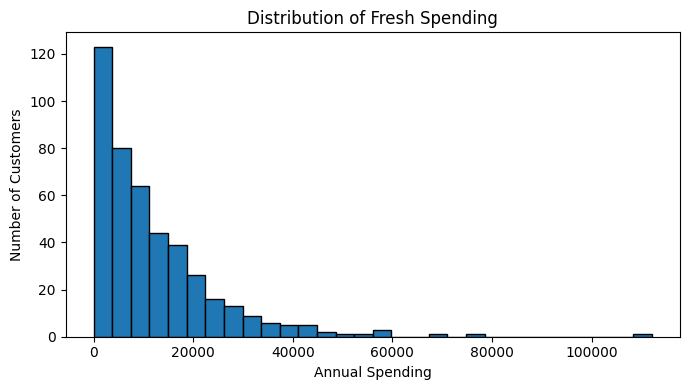

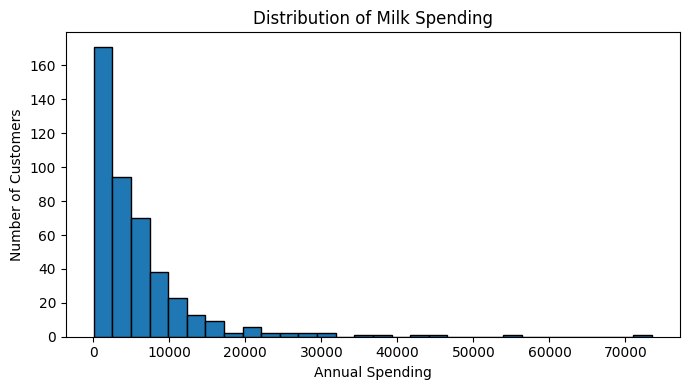

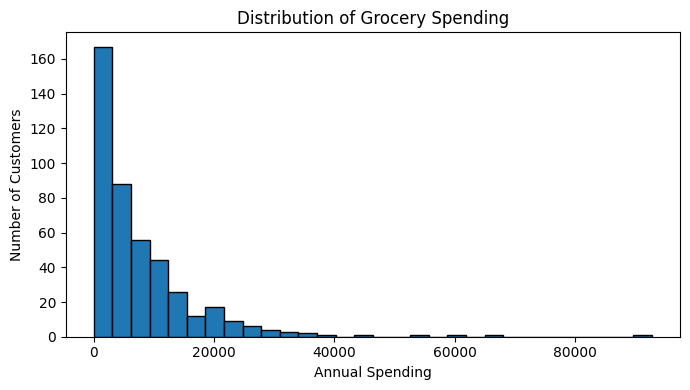

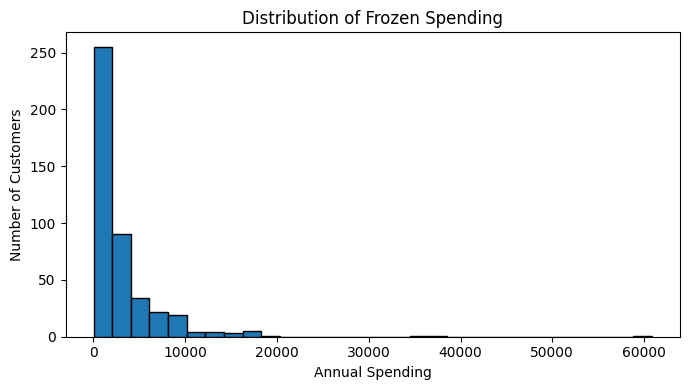

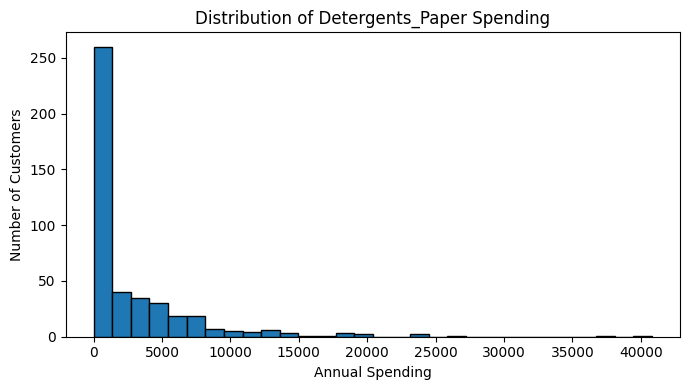

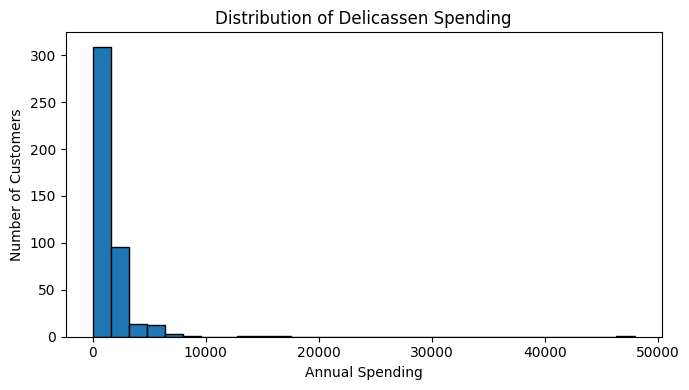

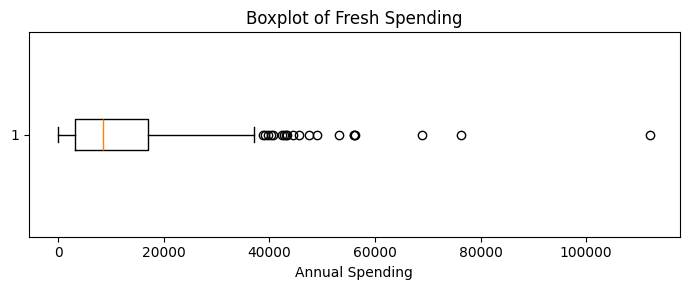

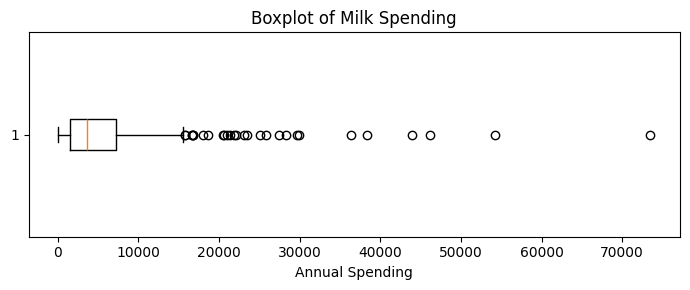

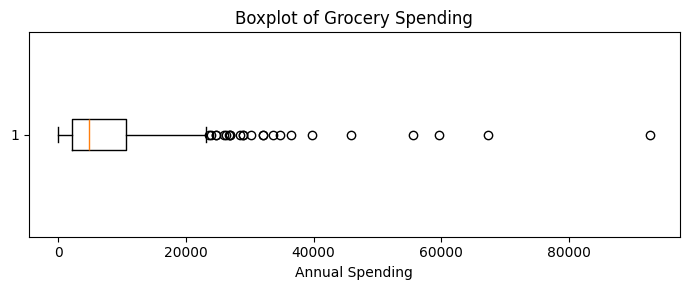

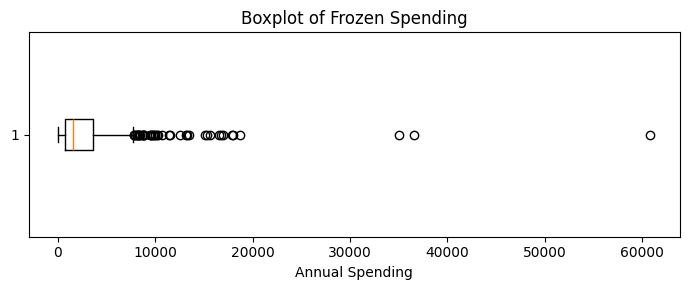

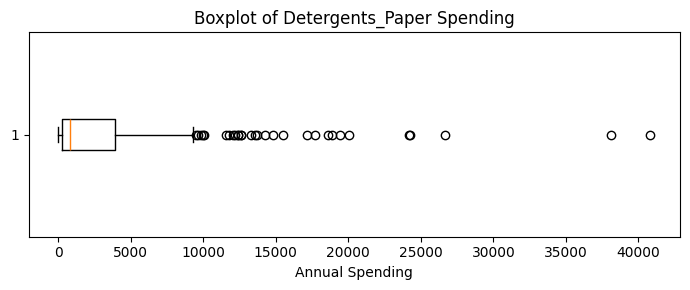

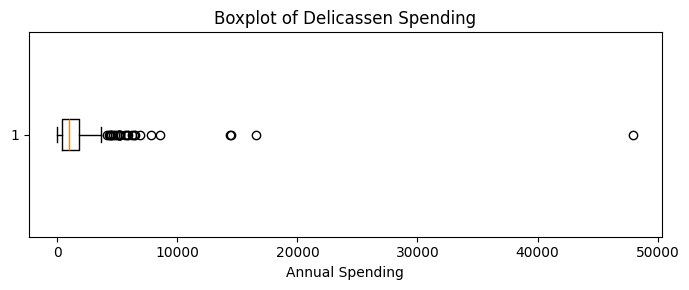

Potential outliers:


,Potential Outliers
Fresh,20
Milk,28
Grocery,24
Frozen,43
Detergents_Paper,30
Delicassen,27


Correlation matrix:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Fresh,1.00,0.10,-0.01,0.35,-0.10,0.24
Milk,0.10,1.00,0.73,0.12,0.66,0.41
Grocery,-0.01,0.73,1.00,-0.04,0.92,0.21
Frozen,0.35,0.12,-0.04,1.00,-0.13,0.39
Detergents_Paper,-0.10,0.66,0.92,-0.13,1.00,0.07
Delicassen,0.24,0.41,0.21,0.39,0.07,1.00


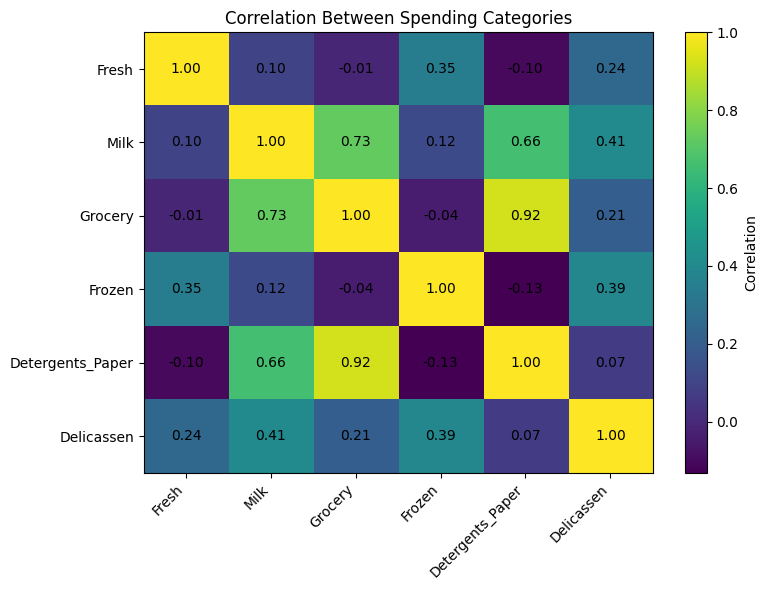

Median spending by Channel:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Channel,,,,,,
1,9581.5,2157.0,2684.0,2057.5,385.5,821.0
2,5993.5,7812.0,12390.0,1081.0,5614.5,1350.0


Median spending by Region:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Region,,,,,,
1,7363.0,3748.0,3838.0,1801.0,737.0,806.0
2,8090.0,2374.0,6114.0,1455.0,811.0,898.0
3,8752.5,3684.5,4732.0,1498.0,856.0,994.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

spending_columns = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

# 1. Descriptive statistics
summary = df_clean[spending_columns].describe().T
summary["Median"] = df_clean[spending_columns].median()
summary["Skewness"] = df_clean[spending_columns].skew()

print("Descriptive statistics:")
display(summary.round(2))


# 2. Histograms
for column in spending_columns:
    plt.figure(figsize=(7, 4))
    plt.hist(df_clean[column], bins=30, edgecolor="black")
    plt.title(f"Distribution of {column} Spending")
    plt.xlabel("Annual Spending")
    plt.ylabel("Number of Customers")
    plt.tight_layout()
    plt.show()


# 3. Boxplots
for column in spending_columns:
    plt.figure(figsize=(7, 3))
    plt.boxplot(df_clean[column], vert=False)
    plt.title(f"Boxplot of {column} Spending")
    plt.xlabel("Annual Spending")
    plt.tight_layout()
    plt.show()


# 4. Potential outliers using the IQR method
outlier_counts = {}

for column in spending_columns:
    q1 = df_clean[column].quantile(0.25)
    q3 = df_clean[column].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outlier_counts[column] = (
        (df_clean[column] < lower_limit) |
        (df_clean[column] > upper_limit)
    ).sum()

outlier_df = pd.DataFrame.from_dict(
    outlier_counts,
    orient="index",
    columns=["Potential Outliers"]
)

print("Potential outliers:")
display(outlier_df)


# 5. Correlation matrix
correlation_matrix = df_clean[spending_columns].corr()

print("Correlation matrix:")
display(correlation_matrix.round(2))

plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(spending_columns)),
    spending_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(spending_columns)),
    spending_columns
)

for i in range(len(spending_columns)):
    for j in range(len(spending_columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Between Spending Categories")
plt.tight_layout()
plt.show()


# 6. Median spending by Channel
channel_medians = (
    df_clean.groupby("Channel", observed=True)[spending_columns]
    .median()
)

print("Median spending by Channel:")
display(channel_medians.round(2))


# 7. Median spending by Region
region_medians = (
    df_clean.groupby("Region", observed=True)[spending_columns]
    .median()
)

print("Median spending by Region:")
display(region_medians.round(2))

In [ ]:
# Create a feature-engineered copy
df_features = df_clean.copy()

# Total and average annual spending
df_features["Total_Spending"] = df_features[spending_columns].sum(axis=1)
df_features["Average_Spending"] = df_features[spending_columns].mean(axis=1)

# Spending proportion for each category
share_columns = []

for column in spending_columns:
    share_name = f"{column}_Share"
    df_features[share_name] = (
        df_features[column] / df_features["Total_Spending"]
    )
    share_columns.append(share_name)

# Customer's highest-spending category
df_features["Dominant_Category"] = (
    df_features[spending_columns].idxmax(axis=1)
)

# Number of categories representing at least 10% of total spending
df_features["Product_Diversity"] = (
    df_features[share_columns] >= 0.10
).sum(axis=1)

print("Engineered features:")
display(
    df_features[
        [
            "Total_Spending",
            "Average_Spending",
            "Dominant_Category",
            "Product_Diversity"
        ] + share_columns
    ].head()
)

# Check for zero-variance features
feature_variance = df_features[spending_columns].var()

print("\nFeature variance:")
display(feature_variance.to_frame(name="Variance"))

# Identify highly correlated feature pairs
correlation_matrix = df_features[spending_columns].corr()
high_correlation_pairs = []

for i in range(len(spending_columns)):
    for j in range(i + 1, len(spending_columns)):
        correlation = correlation_matrix.iloc[i, j]

        if abs(correlation) >= 0.90:
            high_correlation_pairs.append({
                "Feature 1": spending_columns[i],
                "Feature 2": spending_columns[j],
                "Correlation": round(correlation, 3)
            })

print("\nHighly correlated feature pairs:")
display(pd.DataFrame(high_correlation_pairs))

# Final variables selected for clustering
selected_features = spending_columns.copy()

print("\nSelected clustering features:")
print(selected_features)

Engineered features:


,Total_Spending,Average_Spending,Dominant_Category,Product_Diversity,Fresh_Share,Milk_Share,Grocery_Share,Frozen_Share,Detergents_Paper_Share,Delicassen_Share
0,34112,5685.333333,Fresh,3,0.371394,0.283068,0.221652,0.006273,0.078389,0.039224
1,33266,5544.333333,Milk,3,0.212139,0.294896,0.287621,0.052967,0.098990,0.053388
2,36610,6101.666667,Milk,4,0.173532,0.240590,0.209888,0.065692,0.096039,0.214258
3,27381,4563.500000,Fresh,3,0.484460,0.043680,0.154158,0.233885,0.018516,0.065301
4,46100,7683.333333,Fresh,4,0.490564,0.117354,0.156139,0.084924,0.038547,0.112473



Feature variance:


,Variance
Fresh,1.599549e+08
Milk,5.446997e+07
Grocery,9.031010e+07
Frozen,2.356785e+07
Detergents_Paper,2.273244e+07
Delicassen,7.952997e+06



Highly correlated feature pairs:


,Feature 1,Feature 2,Correlation
0,Grocery,Detergents_Paper,0.925



Selected clustering features:
['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']


Scaled feature preview:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.486184,0.976299,0.440155,-1.509250,0.644143,0.408966
1,0.087889,0.990956,0.652171,0.134052,0.766043,0.627926
2,0.016356,0.891151,0.454687,0.376899,0.804405,1.776833
3,0.517477,-0.957973,-0.084792,1.141574,-0.328712,0.633133
4,0.880631,0.439662,0.395847,0.757322,0.404939,1.456588



PCA explained variance:


,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.4408,0.4408
1,PC2,0.2719,0.7127
2,PC3,0.1070,0.8197
3,PC4,0.1010,0.9207
4,PC5,0.0488,0.9695
5,PC6,0.0305,1.0000


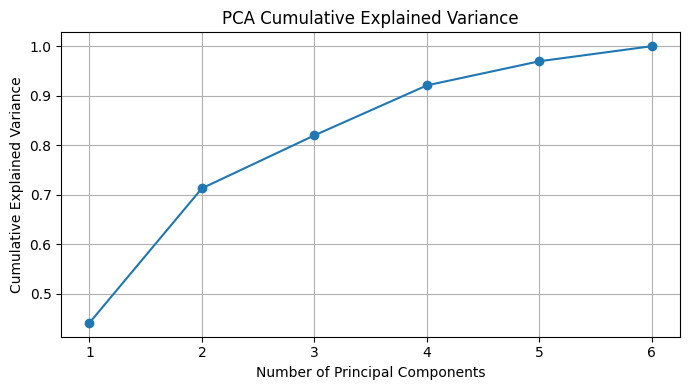


Two-dimensional PCA data:


,PC1,PC2,Channel,Region
0,1.380383,-0.304727,2,3
1,1.438870,0.537468,2,3
2,1.513453,1.232565,2,3
3,-0.825105,1.210790,1,3
4,0.802897,1.766046,2,3



Variance explained by the first two components: 0.7127

PCA feature loadings:


,PC1,PC2
Fresh,-0.105,0.590
Milk,0.542,0.133
Grocery,0.571,-0.006
Frozen,-0.138,0.590
Detergents_Paper,0.551,-0.071
Delicassen,0.214,0.530


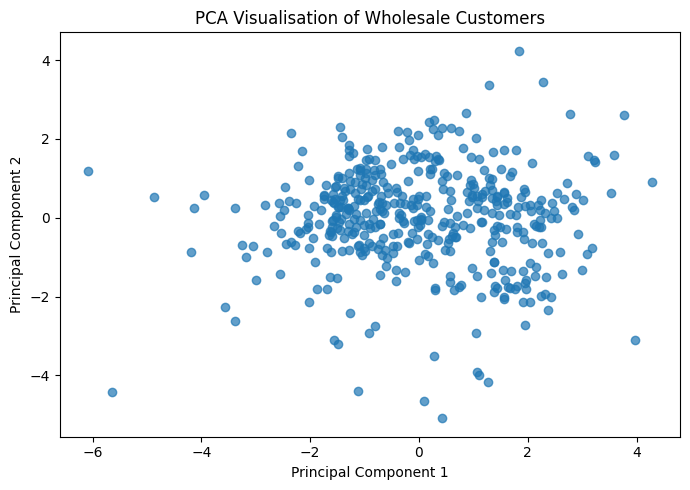

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select the six spending features
X = df_features[selected_features].copy()

# Log transformation to reduce skewness
X_log = np.log1p(X)

# Standardise the transformed features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Store scaled data as a DataFrame
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=selected_features,
    index=df_features.index
)

print("Scaled feature preview:")
display(X_scaled_df.head())

# Apply PCA using all components
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pd.DataFrame({
    "Principal Component": [
        f"PC{i + 1}" for i in range(len(selected_features))
    ],
    "Explained Variance Ratio": pca_full.explained_variance_ratio_,
    "Cumulative Variance": np.cumsum(
        pca_full.explained_variance_ratio_
    )
})

print("\nPCA explained variance:")
display(explained_variance.round(4))

# Plot cumulative explained variance
plt.figure(figsize=(7, 4))
plt.plot(
    range(1, len(selected_features) + 1),
    explained_variance["Cumulative Variance"],
    marker="o"
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.xticks(range(1, len(selected_features) + 1))
plt.grid()
plt.tight_layout()
plt.show()

# Reduce the data to two principal components
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=df_features.index
)

# Retain Channel and Region for later interpretation
pca_df["Channel"] = df_features["Channel"].values
pca_df["Region"] = df_features["Region"].values

print("\nTwo-dimensional PCA data:")
display(pca_df.head())

print(
    "\nVariance explained by the first two components:",
    round(pca_2d.explained_variance_ratio_.sum(), 4)
)

# PCA loadings
pca_loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=selected_features,
    columns=["PC1", "PC2"]
)

print("\nPCA feature loadings:")
display(pca_loadings.round(3))

# PCA visualisation
plt.figure(figsize=(7, 5))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualisation of Wholesale Customers")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Test K-Means with 2 to 10 clusters
kmeans_results = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled_df)

    kmeans_results.append({
        "Clusters": k,
        "Inertia": model.inertia_,
        "Silhouette Score": silhouette_score(X_scaled_df, labels),
        "Davies-Bouldin Index": davies_bouldin_score(
            X_scaled_df, labels
        ),
        "Calinski-Harabasz Score": calinski_harabasz_score(
            X_scaled_df, labels
        )
    })

kmeans_results_df = pd.DataFrame(kmeans_results)

print("K-Means evaluation results:")
display(kmeans_results_df.round(3))

NameError: name 'X_scaled_df' is not defined

NameError: name 'kmeans_results_df' is not defined

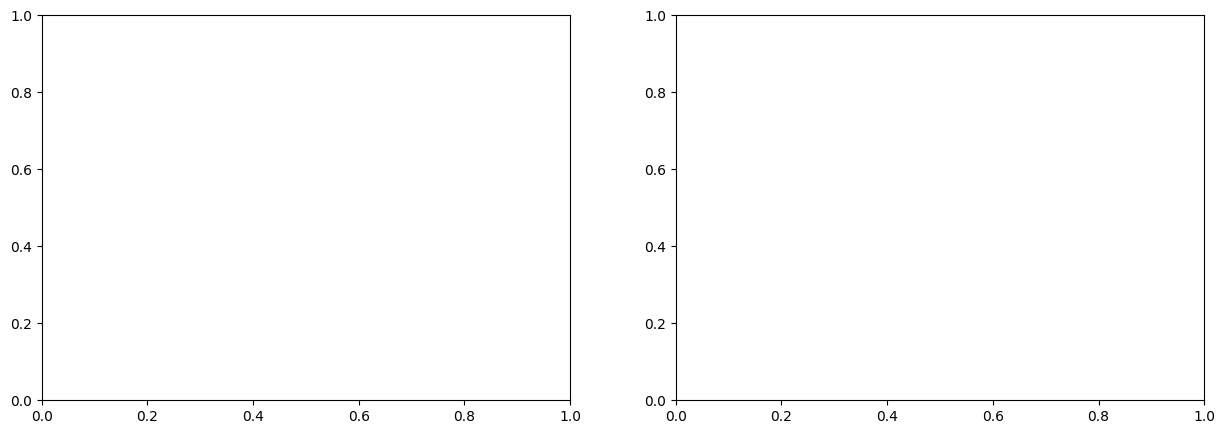

In [ ]:
import matplotlib.pyplot as plt

# Create subplots for Inertia and Silhouette Score
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Elbow Method (Inertia)
ax1.plot(kmeans_results_df['Clusters'], kmeans_results_df['Inertia'], marker='o', linestyle='-', color='b')
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.grid(True)

# Plot 2: Silhouette Score
ax2.plot(kmeans_results_df['Clusters'], kmeans_results_df['Silhouette Score'], marker='o', linestyle='-', color='r')
ax2.set_title('Silhouette Score per Cluster Count')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Load dataset
df = pd.read_csv("/content/Wholesale customers data.csv")

# Select spending features
selected_features = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

X = df[selected_features].copy()

# Log transformation
X_log = np.log1p(X)

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=selected_features,
    index=df.index
)

# Test K-Means from 2 to 10 clusters
kmeans_results = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled_df)

    kmeans_results.append({
        "Clusters": k,
        "Inertia": model.inertia_,
        "Silhouette Score": silhouette_score(X_scaled_df, labels),
        "Davies-Bouldin Index": davies_bouldin_score(
            X_scaled_df, labels
        ),
        "Calinski-Harabasz Score": calinski_harabasz_score(
            X_scaled_df, labels
        )
    })

kmeans_results_df = pd.DataFrame(kmeans_results)

display(kmeans_results_df.round(3))

,Clusters,Inertia,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,2,1844.064,0.290,1.352,189.050
1,3,1553.421,0.259,1.341,152.835
2,4,1386.863,0.188,1.541,131.320
3,5,1266.149,0.192,1.484,118.000
4,6,1174.759,0.201,1.432,108.263
5,7,1086.359,0.196,1.392,103.208
6,8,1028.486,0.185,1.441,96.699
7,9,973.141,0.197,1.383,92.281
8,10,931.998,0.191,1.344,87.559


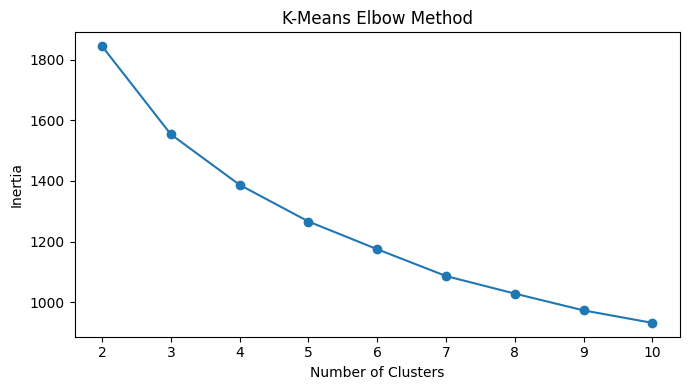

In [ ]:
plt.figure(figsize=(7, 4))

plt.plot(
    kmeans_results_df["Clusters"],
    kmeans_results_df["Inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()


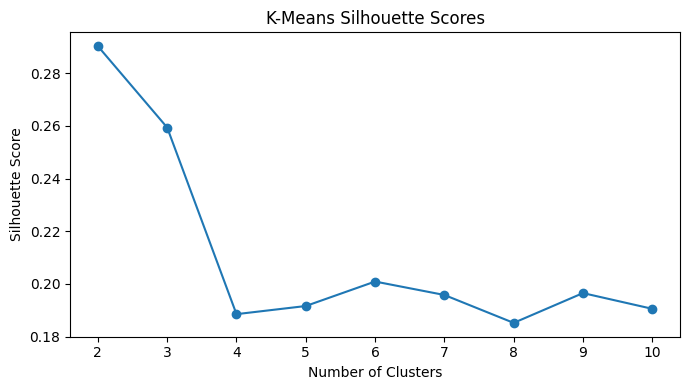

In [ ]:
plt.figure(figsize=(7, 4))

plt.plot(
    kmeans_results_df["Clusters"],
    kmeans_results_df["Silhouette Score"],
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Scores")
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()

In [ ]:
# Select K with the highest Silhouette Score
best_k = int(
    kmeans_results_df.loc[
        kmeans_results_df["Silhouette Score"].idxmax(),
        "Clusters"
    ]
)

print("Best K based on Silhouette Score:", best_k)

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = final_kmeans.fit_predict(X_scaled_df)

# Using 'df' as 'df_features' was not defined in the current session
df["KMeans_Cluster"] = kmeans_labels

print("\nCluster sizes:")
display(
    df["KMeans_Cluster"]
    .value_counts()
    .sort_index()
    .to_frame("Customers")
)

Best K based on Silhouette Score: 2

Cluster sizes:


,Customers
KMeans_Cluster,
0,252
1,188


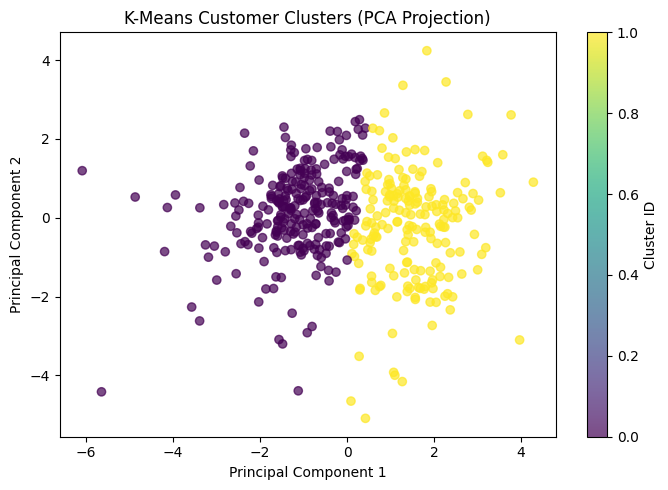

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

# Fix: Check if pca_df exists, otherwise recreate it from X_scaled
try:
    _ = pca_df
except NameError:
    pca_2d = PCA(n_components=2)
    X_pca = pca_2d.fit_transform(X_scaled)
    pca_df = pd.DataFrame(
        X_pca,
        columns=["PC1", "PC2"],
        index=range(len(X_pca))
    )

plt.figure(figsize=(7, 5))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=kmeans_labels,
    cmap='viridis',
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Customer Clusters (PCA Projection)")
plt.colorbar(label='Cluster ID')
plt.tight_layout()
plt.show()

In [ ]:
kmeans_profiles = (
    df
    .groupby("KMeans_Cluster")[selected_features]
    .median()
)

print("Median spending profile by cluster:")
display(kmeans_profiles.round(2))

Median spending profile by cluster:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
KMeans_Cluster,,,,,,
0,10347.5,1871.0,2406.0,2225.0,327.5,749.5
1,5406.5,7690.5,11527.0,1061.5,4495.0,1388.5


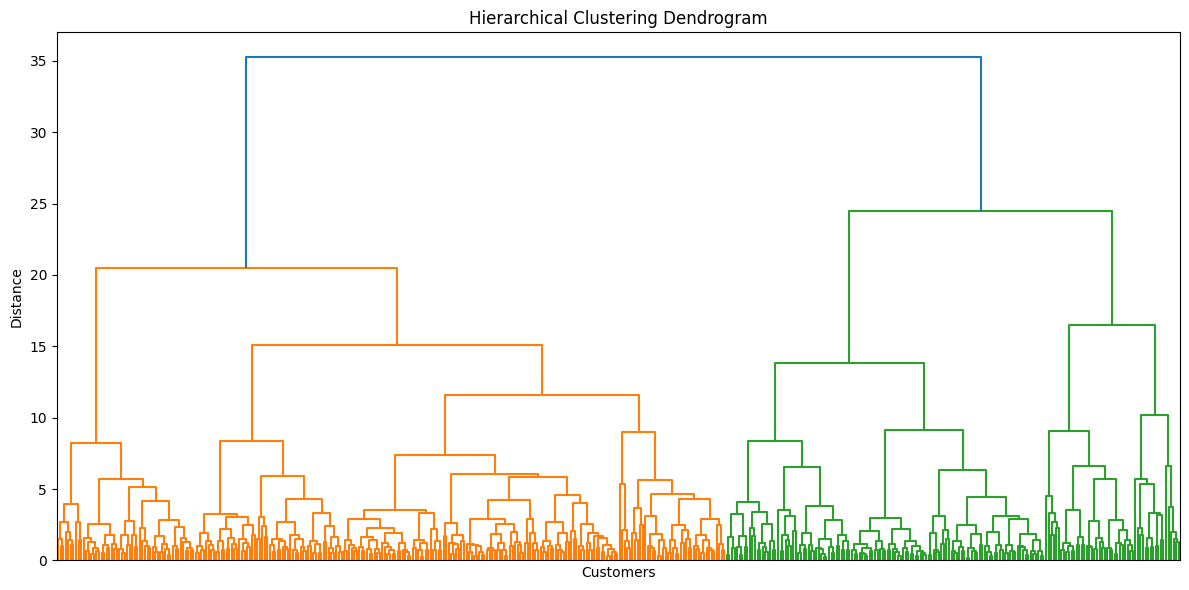

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram

# Load dataset
df = pd.read_csv("/content/Wholesale customers data.csv")

selected_features = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

# Prepare data
X = df[selected_features].copy()
X_log = np.log1p(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=selected_features,
    index=df.index
)

# Create linkage matrix using Ward linkage
linkage_matrix = linkage(X_scaled_df, method="ward")

# Plot dendrogram
plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    no_labels=True
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

hierarchical_results = []

for n_clusters in range(2, 11):

    model = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage="ward"
    )

    labels = model.fit_predict(X_scaled_df)

    hierarchical_results.append({
        "Clusters": n_clusters,
        "Silhouette Score": silhouette_score(X_scaled_df, labels),
        "Davies-Bouldin Index": davies_bouldin_score(
            X_scaled_df, labels
        ),
        "Calinski-Harabasz Score": calinski_harabasz_score(
            X_scaled_df, labels
        )
    })

hierarchical_results_df = pd.DataFrame(hierarchical_results)

print("Hierarchical clustering evaluation results:")
display(hierarchical_results_df.round(3))

Hierarchical clustering evaluation results:


,Clusters,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,2,0.258,1.600,134.624
1,3,0.255,1.539,116.799
2,4,0.202,1.521,108.607
3,5,0.203,1.386,100.015
4,6,0.171,1.490,94.857
5,7,0.163,1.498,91.301
6,8,0.148,1.587,86.612
7,9,0.155,1.549,82.006
8,10,0.122,1.501,77.715


Hierarchical cluster sizes:


,Customers
Hierarchical_Cluster,
0,178
1,262


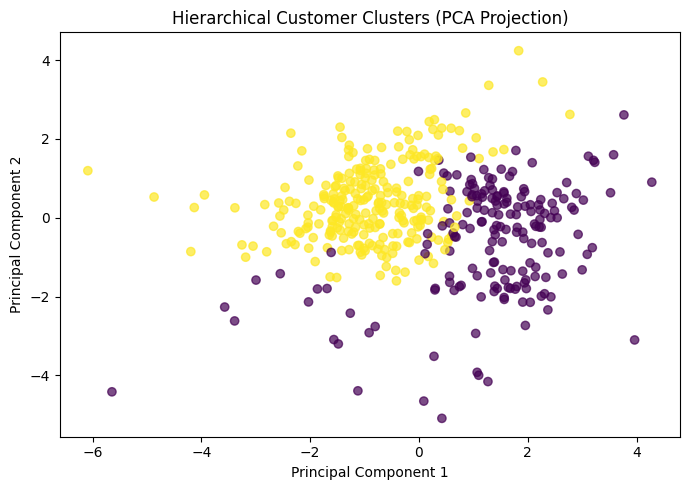

Median spending profile by cluster:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Hierarchical_Cluster,,,,,,
0,4499.5,7339.0,11099.0,957.0,4584.0,1189.0
1,11113.0,2028.0,2583.5,2382.0,358.5,864.0


In [ ]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# Fit final hierarchical model
final_hierarchical = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

hierarchical_labels = final_hierarchical.fit_predict(X_scaled_df)

# Fix: Use 'df' as 'df_features' is not defined in the current session
df["Hierarchical_Cluster"] = hierarchical_labels

# Cluster sizes
print("Hierarchical cluster sizes:")
display(
    df["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
    .to_frame("Customers")
)

# PCA visualisation
plt.figure(figsize=(7, 5))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=hierarchical_labels,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Hierarchical Customer Clusters (PCA Projection)")
plt.tight_layout()
plt.show()

# Median spending profile
hierarchical_profiles = (
    df
    .groupby("Hierarchical_Cluster")[selected_features]
    .median()
)

print("Median spending profile by cluster:")
display(hierarchical_profiles.round(2))

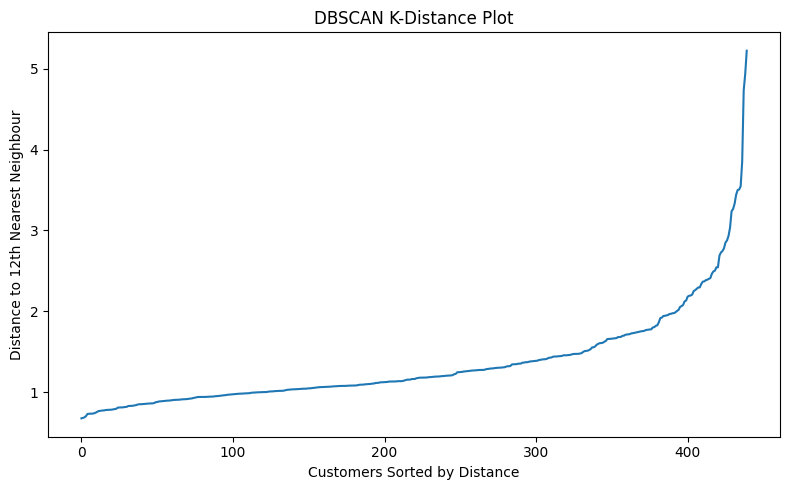

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import NearestNeighbors

# Initial DBSCAN min_samples value
min_samples = 12

# Calculate distances to the 12th nearest neighbour
nearest_neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

nearest_neighbors.fit(X_scaled_df)

distances, indices = nearest_neighbors.kneighbors(X_scaled_df)

# Sort the distance to the furthest neighbour
k_distances = np.sort(distances[:, -1])

# Plot the K-distance graph
plt.figure(figsize=(8, 5))

plt.plot(k_distances)

plt.xlabel("Customers Sorted by Distance")
plt.ylabel(f"Distance to {min_samples}th Nearest Neighbour")
plt.title("DBSCAN K-Distance Plot")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

dbscan_results = []

eps_values = [1.6, 1.8, 2.0, 2.2, 2.4, 2.6]
min_samples_values = [6, 9, 12, 15]

for eps in eps_values:
    for min_samples in min_samples_values:

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = model.fit_predict(X_scaled_df)

        cluster_labels = set(labels)
        number_of_clusters = len(cluster_labels - {-1})
        noise_points = list(labels).count(-1)

        # Evaluate only when at least two clusters exist
        valid_mask = labels != -1
        valid_labels = labels[valid_mask]
        valid_data = X_scaled_df[valid_mask]

        if len(set(valid_labels)) >= 2:
            silhouette = silhouette_score(
                valid_data,
                valid_labels
            )
            davies_bouldin = davies_bouldin_score(
                valid_data,
                valid_labels
            )
            calinski_harabasz = calinski_harabasz_score(
                valid_data,
                valid_labels
            )
        else:
            silhouette = None
            davies_bouldin = None
            calinski_harabasz = None

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "Clusters": number_of_clusters,
            "Noise Points": noise_points,
            "Silhouette Score": silhouette,
            "Davies-Bouldin Index": davies_bouldin,
            "Calinski-Harabasz Score": calinski_harabasz
        })

dbscan_results_df = pd.DataFrame(dbscan_results)

display(dbscan_results_df.round(3))

,eps,min_samples,Clusters,Noise Points,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,1.6,6,1,37,None,None,None
1,1.6,9,1,41,None,None,None
2,1.6,12,1,42,None,None,None
3,1.6,15,1,43,None,None,None
4,1.8,6,1,22,None,None,None
5,1.8,9,1,25,None,None,None
6,1.8,12,1,27,None,None,None
7,1.8,15,1,30,None,None,None
8,2.0,6,1,15,None,None,None
9,2.0,9,1,16,None,None,None


In [ ]:
eps_values = [0.5, 0.7, 0.9, 1.1, 1.3, 1.5]
min_samples_values = [4, 6, 8, 10, 12]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = model.fit_predict(X_scaled_df)

        number_of_clusters = len(set(labels) - {-1})
        noise_points = sum(labels == -1)

        valid_mask = labels != -1
        valid_labels = labels[valid_mask]
        valid_data = X_scaled_df.loc[valid_mask]

        if number_of_clusters >= 2:
            silhouette = silhouette_score(valid_data, valid_labels)
            davies_bouldin = davies_bouldin_score(
                valid_data,
                valid_labels
            )
            calinski_harabasz = calinski_harabasz_score(
                valid_data,
                valid_labels
            )
        else:
            silhouette = None
            davies_bouldin = None
            calinski_harabasz = None

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "Clusters": number_of_clusters,
            "Noise Points": noise_points,
            "Silhouette Score": silhouette,
            "Davies-Bouldin Index": davies_bouldin,
            "Calinski-Harabasz Score": calinski_harabasz
        })

dbscan_results_df = pd.DataFrame(dbscan_results)

display(dbscan_results_df.round(3))

,eps,min_samples,Clusters,Noise Points,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,0.5,4,6,415,0.439,0.730,63.618
1,0.5,6,0,440,NaN,NaN,NaN
2,0.5,8,0,440,NaN,NaN,NaN
3,0.5,10,0,440,NaN,NaN,NaN
4,0.5,12,0,440,NaN,NaN,NaN
5,0.7,4,13,292,0.106,1.021,38.748
6,0.7,6,5,365,0.245,1.154,55.666
7,0.7,8,3,397,0.553,0.695,93.862
8,0.7,10,1,422,NaN,NaN,NaN
9,0.7,12,1,423,NaN,NaN,NaN


In [ ]:
import os
import json
import joblib
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Create model directory
os.makedirs("models", exist_ok=True)

# Refit preprocessing and final model
X = df[selected_features].copy()
X_log = np.log1p(X)

final_scaler = StandardScaler()
X_scaled = final_scaler.fit_transform(X_log)

final_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

final_labels = final_kmeans.fit_predict(X_scaled)

# Fit PCA for visualisation
final_pca = PCA(n_components=2)
final_pca.fit(X_scaled)

# Save model objects
joblib.dump(final_kmeans, "models/kmeans_model.joblib")
joblib.dump(final_scaler, "models/standard_scaler.joblib")
joblib.dump(final_pca, "models/pca_model.joblib")

# Save selected features
with open("models/selected_features.json", "w") as file:
    json.dump(selected_features, file, indent=4)

# Save cluster profiles
df_model_results = df.copy()
df_model_results["KMeans_Cluster"] = final_labels

cluster_profiles = (
    df_model_results
    .groupby("KMeans_Cluster")[selected_features]
    .median()
)

cluster_profiles.to_csv("models/kmeans_cluster_profiles.csv")

print("Final model and preprocessing objects saved successfully.")

Final model and preprocessing objects saved successfully.


Surrogate model accuracy:
1.0

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        38

    accuracy                           1.00        88
   macro avg       1.00      1.00      1.00        88
weighted avg       1.00      1.00      1.00        88

Confusion matrix:


,Predicted Cluster 0,Predicted Cluster 1
Actual Cluster 0,50,0
Actual Cluster 1,0,38


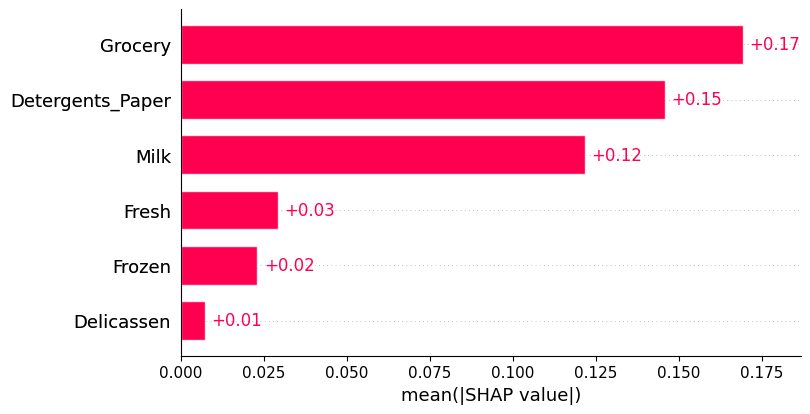

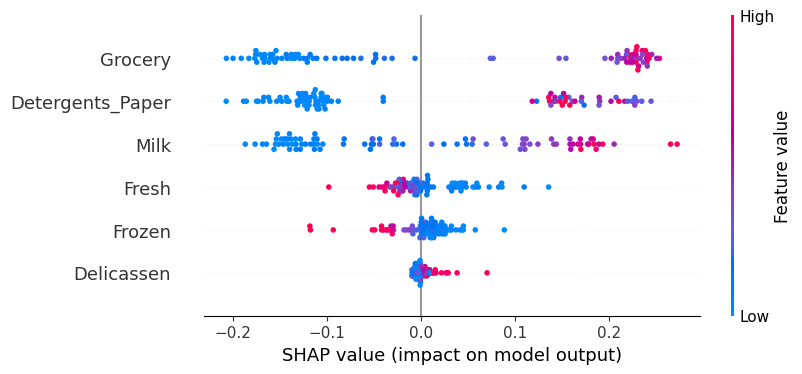


SHAP feature importance:


,Feature,Mean Absolute SHAP Value
2,Grocery,0.1694
4,Detergents_Paper,0.1458
1,Milk,0.1218
0,Fresh,0.0292
3,Frozen,0.0230
5,Delicassen,0.0072


Example customer assigned to Cluster 0:


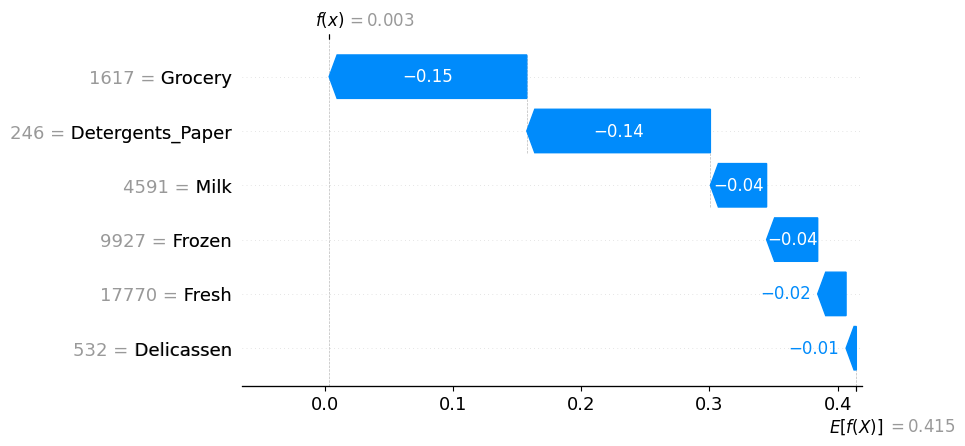

Example customer assigned to Cluster 1:


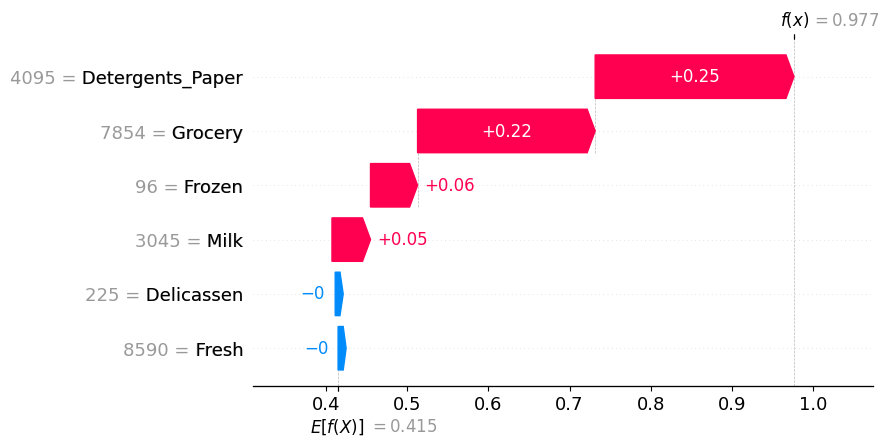

In [ ]:
# Install SHAP if required
!pip install shap -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ---------------------------------------------------
# 1. Recreate the final K-Means cluster assignments
# ---------------------------------------------------

selected_features = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

X_original = df[selected_features].copy()

X_log = np.log1p(X_original)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

final_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

# ---------------------------------------------------
# 2. Train a surrogate Random Forest model
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_original,
    cluster_labels,
    test_size=0.20,
    random_state=42,
    stratify=cluster_labels
)

surrogate_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

surrogate_model.fit(X_train, y_train)

predictions = surrogate_model.predict(X_test)

print("Surrogate model accuracy:")
print(round(accuracy_score(y_test, predictions), 3))

print("\nClassification report:")
print(classification_report(y_test, predictions))

print("Confusion matrix:")
display(pd.DataFrame(
    confusion_matrix(y_test, predictions),
    index=["Actual Cluster 0", "Actual Cluster 1"],
    columns=["Predicted Cluster 0", "Predicted Cluster 1"]
))

# ---------------------------------------------------
# 3. Calculate SHAP values
# ---------------------------------------------------

X_test_reset = X_test.reset_index(drop=True)
y_test_reset = pd.Series(y_test).reset_index(drop=True)

explainer = shap.Explainer(
    surrogate_model,
    X_train
)

shap_output = explainer(X_test_reset)

# Select SHAP values explaining Cluster 1
if shap_output.values.ndim == 3:
    shap_cluster_1 = shap_output[:, :, 1]
else:
    shap_cluster_1 = shap_output

# ---------------------------------------------------
# 4. Global feature importance
# ---------------------------------------------------

shap.plots.bar(
    shap_cluster_1,
    max_display=6
)

# ---------------------------------------------------
# 5. SHAP summary plot
# ---------------------------------------------------

shap.plots.beeswarm(
    shap_cluster_1,
    max_display=6
)

# ---------------------------------------------------
# 6. Mean absolute SHAP importance table
# ---------------------------------------------------

shap_importance = pd.DataFrame({
    "Feature": selected_features,
    "Mean Absolute SHAP Value":
        np.abs(shap_cluster_1.values).mean(axis=0)
}).sort_values(
    "Mean Absolute SHAP Value",
    ascending=False
)

print("\nSHAP feature importance:")
display(shap_importance.round(4))

# ---------------------------------------------------
# 7. Individual customer explanations
# ---------------------------------------------------

cluster_0_position = np.where(y_test_reset == 0)[0][0]
cluster_1_position = np.where(y_test_reset == 1)[0][0]

print("Example customer assigned to Cluster 0:")
shap.plots.waterfall(
    shap_cluster_1[cluster_0_position],
    max_display=6
)

print("Example customer assigned to Cluster 1:")
shap.plots.waterfall(
    shap_cluster_1[cluster_1_position],
    max_display=6
)

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# Ensure cluster labels are present in the current 'df' session
# 'cluster_labels' and 'hierarchical_labels' are stored in the kernel
df["KMeans_Cluster"] = cluster_labels
df["Hierarchical_Cluster"] = hierarchical_labels

# Prepare fairness audit dataset
audit_df = df[["Channel", "Region", "KMeans_Cluster"]].copy()

# Mapping for readability
audit_df["Channel"] = audit_df["Channel"].map({1: "Channel 1", 2: "Channel 2"})
audit_df["Region"] = audit_df["Region"].map({1: "Region 1", 2: "Region 2", 3: "Region 3"})

# 1. Representation counts
for attribute in ["Channel", "Region"]:
    print(f"\nCustomer counts by {attribute} and cluster:")
    display(pd.crosstab(audit_df[attribute], audit_df["KMeans_Cluster"]))

# 2. Cluster assignment rates within each group
for attribute in ["Channel", "Region"]:
    print(f"\nCluster assignment percentages by {attribute}:")
    display((pd.crosstab(audit_df[attribute], audit_df["KMeans_Cluster"], normalize="index") * 100).round(2))

# 3. Composition of each cluster
for attribute in ["Channel", "Region"]:
    print(f"\nComposition of each cluster by {attribute}:")
    display((pd.crosstab(audit_df[attribute], audit_df["KMeans_Cluster"], normalize="columns") * 100).round(2))

# 4. Representation parity metrics
parity_results = []
for attribute in ["Channel", "Region"]:
    rates = pd.crosstab(audit_df[attribute], audit_df["KMeans_Cluster"], normalize="index")
    for cluster in rates.columns:
        c_rates = rates[cluster]
        parity_results.append({
            "Attribute": attribute,
            "Cluster": cluster,
            "Max Rate": c_rates.max(),
            "Min Rate": c_rates.min(),
            "Parity Difference": c_rates.max() - c_rates.min(),
            "Parity Ratio": c_rates.min() / c_rates.max() if c_rates.max() > 0 else np.nan
        })

print("\nRepresentation parity results:")
display(pd.DataFrame(parity_results).round(3))

# 5. Chi-square and Cramer's V
association_results = []
for attribute in ["Channel", "Region"]:
    table = pd.crosstab(audit_df[attribute], audit_df["KMeans_Cluster"])
    chi2, p_val, dof, ex = chi2_contingency(table)
    n = table.sum().sum()
    r, c = table.shape
    # Cramer's V calculation
    v = np.sqrt((chi2 / n) / min(r - 1, c - 1)) if n > 0 else 0
    association_results.append({
        "Attribute": attribute,
        "Chi-Square": chi2,
        "P-Value": p_val,
        "Cramers V": v
    })

print("\nAssociation between groups and cluster membership:")
display(pd.DataFrame(association_results).round(4))


Customer counts by Channel and cluster:


KMeans_Cluster,0,1
Channel,,
Channel 1,244,54
Channel 2,8,134



Customer counts by Region and cluster:


KMeans_Cluster,0,1
Region,,
Region 1,48,29
Region 2,28,19
Region 3,176,140



Cluster assignment percentages by Channel:


...

KMeans_Cluster,0,1
Region,,
Region 1,19.05,15.43
Region 2,11.11,10.11
Region 3,69.84,74.47



Representation parity results:


,Attribute,Cluster,Max Rate,Min Rate,Parity Difference,Parity Ratio
0,Channel,0,0.819,0.056,0.762,0.069
1,Channel,1,0.944,0.181,0.762,0.192
2,Region,0,0.623,0.557,0.066,0.893
3,Region,1,0.443,0.377,0.066,0.850



Association between groups and cluster membership:


,Attribute,Chi-Square,P-Value,Cramers V
0,Channel,225.3633,0.0000,0.7157
1,Region,1.2299,0.5407,0.0529
